In [29]:
import pickle as pkl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [46]:
def results_to_df(results_list, dataset, sampling_method):
    res = []
    for config in results_list:
        if sampling_method.endswith("_dp"):
            e = config["e"]
        else:
            e = np.inf
        b = config["b"]
        test_bacc = config["test_bacc"]
        e_est = config["e_est"]
        res.append((dataset, sampling_method, e, b, test_bacc, e_est))
    
    return pd.DataFrame.from_records(res, columns=["dataset", "sampling", "e", "b", "test_bacc", "e_est"])

In [47]:
DATASET = "ml1m"
PATH = DATASET + "/"
with open(PATH + "attacker.random_dp", "rb") as f:
    results = pkl.load(f)
    random_dp_df = results_to_df(results, DATASET, "random_dp")
with open(PATH + "attacker.ister_dp", "rb") as f:
    results = pkl.load(f)
    ister_dp_df = results_to_df(results, DATASET, "ister_dp")
with open(PATH + "attacker.random_del", "rb") as f:
    results = pkl.load(f)
    random_del_df = results_to_df(results, DATASET, "random_del")
with open(PATH + "attacker.ister_del", "rb") as f:
    results = pkl.load(f)
    ister_del_df = results_to_df(results, DATASET, "ister_del")


results_df = pd.concat([random_dp_df, ister_dp_df, random_del_df, ister_del_df]).reset_index(drop=True)
results_df.head()

,dataset,sampling,e,b,test_bacc,e_est
0,ml1m,random_dp,inf,1.0,0.711772,1.567844
1,ml1m,random_dp,3.0,0.8,0.727891,1.645038
2,ml1m,random_dp,3.0,0.6,0.730275,1.664448
3,ml1m,random_dp,3.0,0.4,0.709686,1.600061
4,ml1m,random_dp,3.0,0.2,0.735275,1.694304


Text(0, 0.5, 'BAcc')

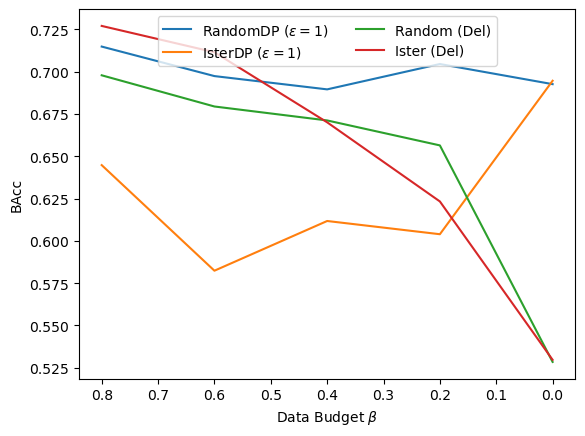

In [55]:
rand = results_df[(results_df["sampling"] == "random_dp") & (results_df["e"] == 1)]
plt.plot(rand["b"], rand["test_bacc"], label=r"RandomDP ($\varepsilon=1$)", c="C0")
ister = results_df[(results_df["sampling"] == "ister_dp") & (results_df["e"] == 1)]
plt.plot(ister["b"], ister["test_bacc"], label=r"IsterDP ($\varepsilon=1$)", c="C1")

rand = results_df[(results_df["sampling"] == "random_del")]
plt.plot(rand["b"], rand["test_bacc"], label=r"Random (Del)", c="C2")
ister = results_df[(results_df["sampling"] == "ister_del")]
plt.plot(ister["b"], ister["test_bacc"], label=r"Ister (Del)", c="C3")


plt.gca().invert_xaxis()

plt.legend(ncol=2, loc="upper center")
plt.xlabel(r"Data Budget $\beta$")
plt.ylabel("BAcc")

Text(0, 0.5, '$\\varepsilon_{est}$')

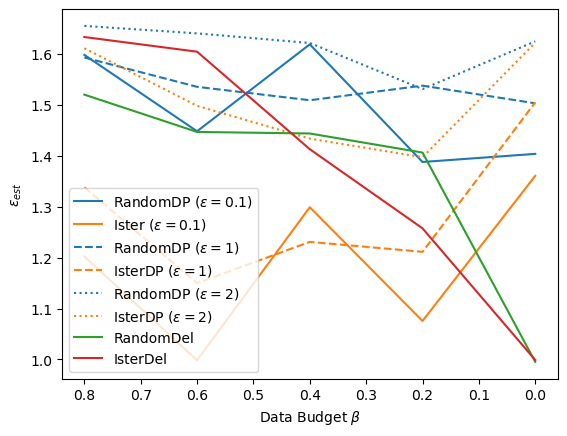

In [51]:
rand = results_df[(results_df["sampling"] == "random_dp") & (results_df["e"] == 0.1)]
plt.plot(rand["b"], rand["e_est"], label=r"RandomDP ($\varepsilon=0.1$)", c="C0")
ister = results_df[(results_df["sampling"] == "ister_dp") & (results_df["e"] == 0.1)]
plt.plot(ister["b"], ister["e_est"], label=r"Ister ($\varepsilon=0.1$)", c="C1")

rand = results_df[(results_df["sampling"] == "random_dp") & (results_df["e"] == 1)]
plt.plot(rand["b"], rand["e_est"], label=r"RandomDP ($\varepsilon=1$)", c="C0", linestyle="dashed")
ister = results_df[(results_df["sampling"] == "ister_dp") & (results_df["e"] == 1)]
plt.plot(ister["b"], ister["e_est"], label=r"IsterDP ($\varepsilon=1$)", c="C1", linestyle="dashed")

rand = results_df[(results_df["sampling"] == "random_dp") & (results_df["e"] == 2)]
plt.plot(rand["b"], rand["e_est"], label=r"RandomDP ($\varepsilon=2$)", c="C0", linestyle="dotted")
ister = results_df[(results_df["sampling"] == "ister_dp") & (results_df["e"] == 2)]
plt.plot(ister["b"], ister["e_est"], label=r"IsterDP ($\varepsilon=2$)", c="C1", linestyle="dotted")

rand = results_df[(results_df["sampling"] == "random_del")]
plt.plot(rand["b"], rand["e_est"], label=r"RandomDel", c="C2")
ister = results_df[(results_df["sampling"] == "ister_del")]
plt.plot(ister["b"], ister["e_est"], label=r"IsterDel", c="C3")


plt.gca().invert_xaxis()

plt.legend()
plt.xlabel(r"Data Budget $\beta$")
plt.ylabel(r"$\varepsilon_{est}$")

In [52]:
rand

,dataset,sampling,e,b,test_bacc,e_est
42,ml1m,random_del,inf,0.8,0.697804,1.519826
43,ml1m,random_del,inf,0.6,0.679375,1.446594
44,ml1m,random_del,inf,0.4,0.671134,1.443533
45,ml1m,random_del,inf,0.2,0.656392,1.406097
46,ml1m,random_del,inf,0.0,0.528483,0.995199


In [54]:
np.exp(0.99)

2.691234472349262